In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from PIL import Image
import sklearn
import os
# %matplotlib inline

#### A few notes before we start
- Anything that starts with <strong>%</strong> in a Jupyter notebook is a <strong>Jupyter magic command</strong>, NOT standard Python syntax, meaning it won't work / will error in a .py script. In particular, the purpose of `%matplotlib inline` is for making plots render inline, but in modern Jupyter environments, that usually is already the default, so `%matplotlib inline` is often unnecessary. If the plots don't show, use `plt.show()` -- in a normal .py script, you need `plt.show()` for plots to render anyway. So my suggestion is to remove `%matplotlib inline` for cleaner Python habits from the start.
- Jupyter notebooks automatically displays the value of the last expression in a cell, which is convenient for quick exploration. However, this is <strong>notebook-specific behavior</strong>, not a general Python rule. For clearer and more transferable coding habits, prefer `print(...)` when you want textual outputs explicitly. However, an exception is that `print(Pandas.DataFrame)` is <i>very</i> unaesthetic... in Jupyter, `display(Pandas.DataFrame)` gives better, more interpretable rendering.

> So the take-home message is not "Jupyter notebook commands are bad because they're not pure Python"; it's "understanding the environment you're working in / with and using the appropriate tools."

-- 𝒜𝓂𝒶𝓃𝒹𝒶 ℒ𝒾𝓃

In [2]:
iris = load_iris()

print(f"type(iris) = {type(iris)}")
print(f"issubclass(type(iris), dict): {issubclass(type(iris), dict)}\n")

print("class attributes:")
for attr in dir(iris):
    print("  ", attr)

print(f"\n iris attributes == iris keys: {set(dir(iris)) == set(iris.keys())}")

type(iris) = <class 'sklearn.utils._bunch.Bunch'>
issubclass(type(iris), dict): True

class attributes:
   DESCR
   data
   data_module
   feature_names
   filename
   frame
   target
   target_names

 iris attributes == iris keys: True


In [14]:
keys_and_type = {k: type(v) for k, v in iris.items()}
print(keys_and_type)

{'data': <class 'numpy.ndarray'>, 'target': <class 'numpy.ndarray'>, 'frame': <class 'NoneType'>, 'target_names': <class 'numpy.ndarray'>, 'DESCR': <class 'str'>, 'feature_names': <class 'list'>, 'filename': <class 'str'>, 'data_module': <class 'str'>}


In [146]:
data = iris["data"]
feature_names = iris["feature_names"]

print(f"data.shape (n_samples, n_features) = {data.shape}")
print(f"data.dtype = {data.dtype}")
print(f"len(feature_names) = n_features = {len(feature_names)}")

data2 = iris.data
feature_names2 = iris.feature_names

print(f"iris['data'] and iris.data are equal: {np.array_equal(data, data2)}")
print(f"iris['feature_names'] and iris.feature_names are equal: {feature_names == feature_names2}")

data.shape (n_samples, n_features) = (150, 4)
data.dtype = float64
len(feature_names) = n_features = 4
iris['data'] and iris.data are equal: True
iris['feature_names'] and iris.feature_names are equal: True


In [147]:
arr1 = np.array(["a", "b", "c"])
arr2 = np.array([["aa"], ["bb"], ["cc"]])
arr3 = np.array([int(1), int(2), int(3)])
arr4 = np.array([1.0, 2, 3])
try:
    arr5 = np.array(["a", ["b"], 3])
except ValueError as e:
    print(f"\n{e}")
    arr5 = np.array(["a", ["b"], 3], dtype=object)

arrs = [arr1, arr2, arr3, arr4, arr5]
for i, arr in enumerate(arrs):
    print(f"\narr{i+1} = {arr}")
    print(f"   type(arr{i+1}) = {type(arr)}")
    print(f"   arr{i+1}.dtype = {arr.dtype}")


setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

arr1 = ['a' 'b' 'c']
   type(arr1) = <class 'numpy.ndarray'>
   arr1.dtype = <U1

arr2 = [['aa']
 ['bb']
 ['cc']]
   type(arr2) = <class 'numpy.ndarray'>
   arr2.dtype = <U2

arr3 = [1 2 3]
   type(arr3) = <class 'numpy.ndarray'>
   arr3.dtype = int64

arr4 = [1. 2. 3.]
   type(arr4) = <class 'numpy.ndarray'>
   arr4.dtype = float64

arr5 = ['a' list(['b']) 3]
   type(arr5) = <class 'numpy.ndarray'>
   arr5.dtype = object


In [3]:
class DictWrapper:
    def __init__(self, **kwargs):
        self.data = kwargs
        
    def __getitem__(self, key):
        if key in self.data:
            return self.data[key]
        else:
            raise KeyError(f"OoOoopseiiiee! {key} not in keys...")
    
    def __contains__(self, item):
        return item in self.data
    
    def __setitem__(self, key, value):
        self.data[key] = value


class DictFromHashTable:
    def __init__(self, *args, n_buckets: int=10):
        if not all((isinstance(arg, tuple)) and len(arg) == 2 for arg in args) :
            raise ValueError("Input positional arguments must all be tuples of length 2")
        if type(n_buckets) is not int or n_buckets <= 0:
            raise ValueError("n_buckets must be an integer >= 1")
        
        # Works, but can use __setitem__ directly
        #hashes = [(hash(key) % n_buckets, (key, value)) for key, value in args]
        #self.buckets = [[h[1] for h in hashes if h[0] == i] for i in range(n_buckets)]
        
        self._items = []
        self.buckets = [[] for _ in range(n_buckets)]
        self.length = 0
        self.n_buckets = n_buckets
        for key, value in args:
            self[key] = value  # equivalent to self.__setitem__(key, value)

    def __getitem__(self, key):
        search_range = self.buckets[hash(key) % self.n_buckets]
        # This version uses two linear searches -- not optimal
        #existing_keys = [tup[0] for tup in search_range]
        #try:
            #return search_range[existing_keys.index(key)][1]
        #except ValueError:
            #raise KeyError(f"OoOoopseiiiee! {key} not in keys...")
        for stored_key, stored_val in search_range:
            if stored_key == key:
                return stored_val
        raise KeyError(f"OoOoopseiiiee! {key} not in keys...")
        
    def __contains__(self, key):
        search_range = self.buckets[hash(key) % self.n_buckets]
        for stored_key, _ in search_range:
            if stored_key == key:
                return True
        return False

    def __setitem__(self, key, value):
        search_range = self.buckets[hash(key) % self.n_buckets]
        for i, (stored_key, stored_val) in enumerate(search_range):
            if stored_key == key:
                search_range[i] = (key, value)
                self._items[self._items.index((stored_key, stored_val))] = (key, value)
                return
        search_range.append((key, value))
        self.length += 1
        self._items.append((key, value))

    def __len__(self):
        return self.length
    
    def __delitem__(self, key):
        search_range = self.buckets[hash(key) % self.n_buckets]
        for i, (stored_key, stored_val) in enumerate(search_range):
            if stored_key == key:
                # search_range.remove((stored_key, stored_val)) <- remove searches the list again; delete directly using index 
                del search_range[i]
                self.length -= 1
                self._items.remove((stored_key, stored_val))
                return
        raise KeyError(f"OoOoopseiiiee! {key} not in keys...")
    
    def items(self):
        return list(self._items)
    
    def keys(self):
        return [item[0] for item in self._items]
    
    def values(self):
        return [item[1] for item in self._items]
        

d_wrapper = DictWrapper(Installation=1, Bash=2, GitHub=2, Python=4) 
print(f"type(d_wrapper) = {type(d_wrapper)}") 
print(f"issubclass(type(d_wrapper), dict): {issubclass(type(d_wrapper), dict)}")
print(f"d_wrapper['Python'] = {d_wrapper['Python']}\n")


d_from_hash = DictFromHashTable(("Amanda",1), ("racoon",2), ("brain",3), ("ML",4), ("DL",5), ("ChatGPT",6), ("EEG",7))
print(f"type(d_from_hash) = {type(d_from_hash)}")
print(f"issubclass(type(d_from_hash), dict): {issubclass(type(d_from_hash), dict)}")
print(f"len(d_from_hash) = {len(d_from_hash)}")
print(f"d_from_hash['brain'] = {d_from_hash['brain']}")
print(f"d_from_hash.keys() = {d_from_hash.keys()}")
d_from_hash["NTU"] = 0
d_from_hash["Amanda"] = 100
print(f"d_from_hash.items() = {d_from_hash.items()}")
del d_from_hash["brain"]
try:
    print(d_from_hash["brain"])
except KeyError as e:
    print(e)


type(d_wrapper) = <class '__main__.DictWrapper'>
issubclass(type(d_wrapper), dict): False
d_wrapper['Python'] = 4

type(d_from_hash) = <class '__main__.DictFromHashTable'>
issubclass(type(d_from_hash), dict): False
len(d_from_hash) = 7
d_from_hash['brain'] = 3
d_from_hash.keys() = ['Amanda', 'racoon', 'brain', 'ML', 'DL', 'ChatGPT', 'EEG']
d_from_hash.items() = [('Amanda', 100), ('racoon', 2), ('brain', 3), ('ML', 4), ('DL', 5), ('ChatGPT', 6), ('EEG', 7), ('NTU', 0)]
'OoOoopseiiiee! brain not in keys...'


In [107]:
class ManualBunch(dict):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError:
            raise AttributeError (f"No attribute {key}") from None
    
    def __setattr__(self, key, value):
        self[key] = value
    
    def __setitem__(self, key, value):
        super().__setitem__(key, value)
        self.__dict__[key] = value

    def __delattr__(self, key):
        del self[key]  # eqiovalent to super().__delitem__(key)


mb = ManualBunch({"DESCR": iris.DESCR}, filename=iris.filename, feature_names=iris["feature_names"])   
print(f"type(mb) = {type(mb)}")
print(f"isinstance(mb, dict): {isinstance(mb, dict)}")
print(f"issubclass(type(mb), dict): {issubclass(type(mb), dict)}")
print(f"isinstance(mb, sklearn.utils._bunch.Bunch): {isinstance(mb, sklearn.utils._bunch.Bunch)}\n")
print(f"mb.feature_names == mb['feature_names']: {mb.feature_names == mb['feature_names']}")
mb.data = iris.data
print(f"mb['data'].shape = {mb['data'].shape}")
mb["target"] = iris["target"]
print(f"mb.target.shape = {mb.target.shape}\n")

del mb.DESCR
try:
    print(mb["DESCR"])
except KeyError as e:
    print(f"KeyError: {e}")

del mb["filename"]
try:
    print(mb.filename)
except AttributeError as e:
    print(f"AttributeError: {e}")



type(mb) = <class '__main__.ManualBunch'>
isinstance(mb, dict): True
issubclass(type(mb), dict): True
isinstance(mb, sklearn.utils._bunch.Bunch): False

mb.feature_names == mb['feature_names']: True
mb['data'].shape = (150, 4)
mb.target.shape = (150,)

KeyError: 'DESCR'
AttributeError: No attribute filename


In [ ]:
df = pd.DataFrame(data, columns=feature_names)
display(df.head(3))

# rename columns to remove (cm)
df = df.rename(mapper=lambda s: s.replace(" (cm)", ""), axis=1)
display(df.head(3))

# or even shorter
def shorten(s):
    splitted = s.split(" ")
    return splitted[0][0] + splitted[1][0]
df = df.rename(mapper=shorten, axis=1)
display(df.head(3))
print("...")
print(f"{len(df)} rows x {len(df.columns)} columns\n")

with pd.option_context("display.precision", 2): # show only two decimal points
    display(df.describe())


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


,sepal length,sepal width,petal length,petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


,sl,sw,pl,pw
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


...
150 rows x 4 columns



,sl,sw,pl,pw
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [ ]:
df1 = df.iloc[:50]
df2 = df.loc[:49]
print(np.array_equal(df1.to_numpy(), df2.to_numpy())) # checking that they are equal

# sort by sepal length value in descending order
# now the indices are mixed up
df_sorted = df.sort_values(by="sl", key=lambda x: -x, inplace=False)
display(df_sorted.head())
print("...\n")

df1 = df_sorted.iloc[:50]  # select the first 50 rows
df2 = df_sorted.loc[:49]   # select all the rows from row 0 to the row with name (df.index) 49 
print(np.array_equal(df1.to_numpy(), df2.to_numpy())) # checking that they are NOT equal
print(f"\n >> df1 has {len(df1)} rows; df2 has {len(df2)} rows")


True


,sl,sw,pl,pw
131,7.9,3.8,6.4,2.0
122,7.7,2.8,6.7,2.0
117,7.7,3.8,6.7,2.2
118,7.7,2.6,6.9,2.3
135,7.7,3.0,6.1,2.3


...

False

 >> df1 has 50 rows; df2 has 120 rows


In [ ]:
def find_extremes_vectorized(df: pd.DataFrame, thresh: float= 1.5, criterion="std", query=None):  # argument type hints
  """Unleashing the power of Pandas... Also, 3.9 * std is kinda too 'extreme EXTREME'..."""       # function doc string
  if criterion.lower() == "std":
      means, stds = df.mean(axis=0), df.std(axis=0)
      lowers, uppers = means - thresh * stds, means + thresh * stds

  elif criterion.lower() == "iqr":
      q1s, q3s = df.quantile(q=0.25, axis=0), df.quantile(q=0.75, axis=0)
      iqrs = q3s - q1s
      lowers, uppers = q1s - thresh * iqrs, q3s + thresh * iqrs

  else:
      raise ValueError ("Invalid criterion input!")

  res = df[(df < lowers) | (df > uppers)] # boolean masking

  if query and query in df.columns:
      display(res[query].dropna())

  return res

res1 = find_extremes_vectorized(df, thresh=1.5, criterion="std", query="pl")
res2 = find_extremes_vectorized(df, criterion="iqr", query="sw")

13     1.1
22     1.0
105    6.6
117    6.7
118    6.9
122    6.7
Name: pl, dtype: float64

15    4.4
32    4.1
33    4.2
60    2.0
Name: sw, dtype: float64

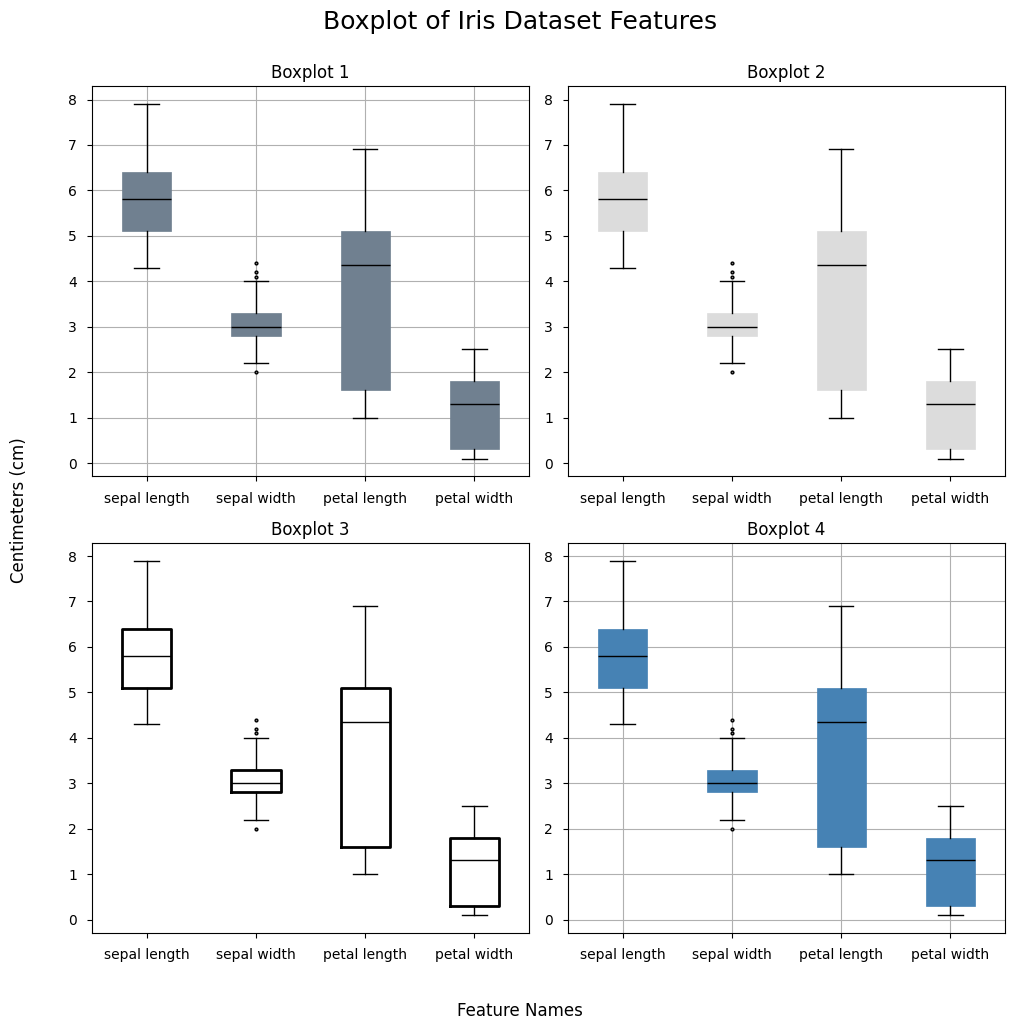

Listing files in current directory using Python `os`:
['.config', 'iris_data.csv', 'iris-redundant-boxplots.png', 'sample_data']

Listing files in current directory using underlying OS command:
iris_data.csv  iris-redundant-boxplots.png  sample_data


In [ ]:
# this is excessive/redundant for one iris dataset, but i'm just showing what subplots are

NROWS, NCOLS = 2, 2 

patch_artist_list = [True, True, False, True]
grid_list = [True, False, False, True]
alphas = [1.0, 1,0, None, 0.01]
edgecolors = ["slategrey", "gainsboro", "royalblue", "steelblue"]
facecolors = edgecolors.copy()
boxprops_list = [dict(facecolor=face, edgecolor=edge, alpha=alpha, linewidth=0.5) if patch else dict(linewidth=2)
                                      for face, edge, patch, alpha in zip(facecolors, edgecolors, patch_artist_list, alphas)]


df_ = df.rename(mapper=lambda x: x.split("(")[0].strip(), axis=1) # <- renames it so the '(cm)'s won't show in the x labels
fig, axes = plt.subplots(nrows=NROWS, ncols=NCOLS, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    df_.boxplot(ax=ax,
               grid=grid_list[i],
               patch_artist=patch_artist_list[i],
               boxprops=boxprops_list[i],
               medianprops=dict(color="black", linewidth=1),
               whiskerprops=dict(color="black", linewidth=1),
               capprops=dict(color="black", linewidth=1),
               flierprops=dict(
               marker="o",
               markerfacecolor="grey",
               markeredgecolor="black",
               markersize=2))

    ax.set_title(f"Boxplot {i+1}")
    ax.tick_params(axis="x", labelsize=10, pad=7.5)
    ax.tick_params(axis="y", labelsize=10, pad=7.5)
fig.supxlabel("Feature Names", fontsize=12, y=-0.01)
fig.supylabel("Centimeters (cm)", fontsize=12, x=-0.01)
fig.suptitle("Boxplot of Iris Dataset Features", fontsize=18, y=1)
fig.tight_layout()

plt.savefig("iris-redundant-boxplots.png", bbox_inches="tight") #💡 `bbox_inches="tight"` so the labels don't get cut off...
plt.show()
plt.close()

df.to_csv("iris_data.csv", index=False)

print("Listing files in current directory using Python `os`:")
print(os.listdir())
print("\nListing files in current directory using underlying OS command:")
!ls  # can do terminal commands in ipynb notebooks with an exclamation mark prefix

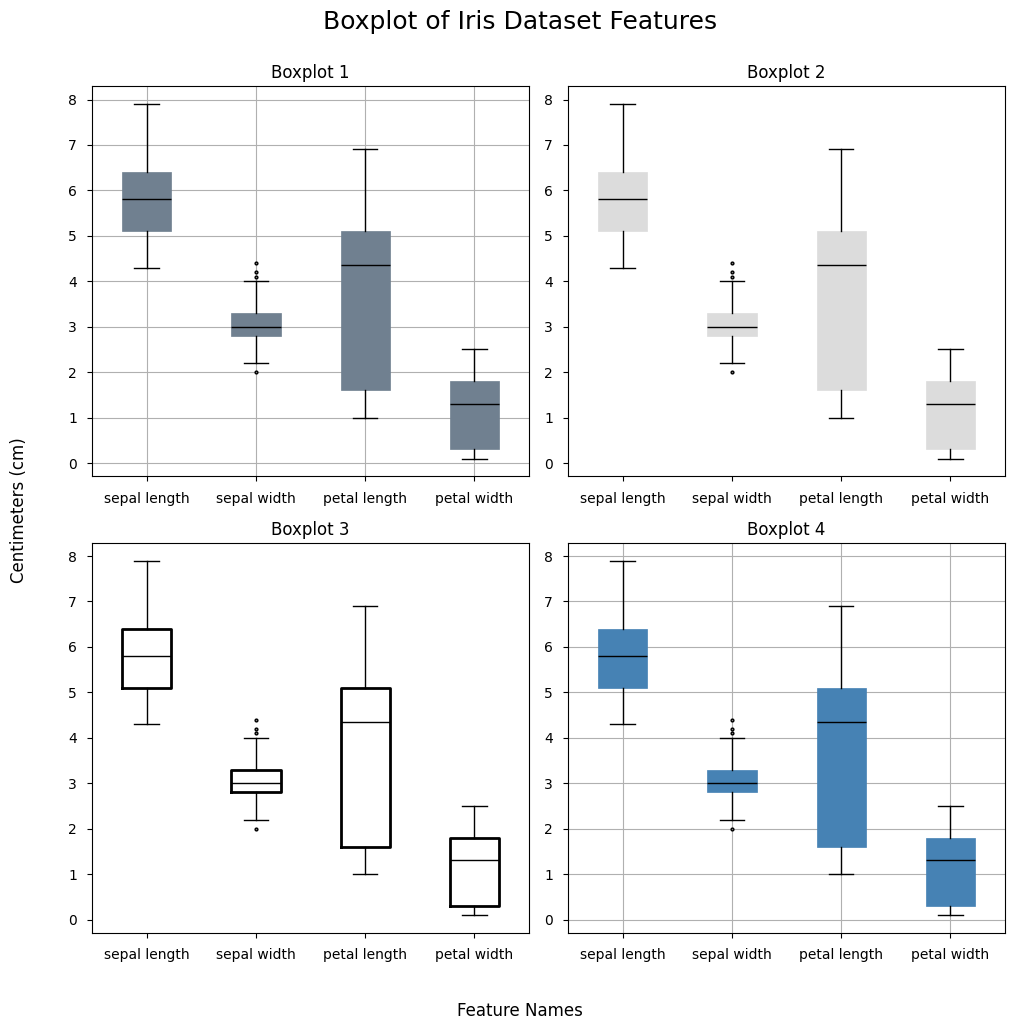

In [ ]:
#Just sanity-checking... importing the saved PNG back...

img = Image.open("iris-redundant-boxplots.png")
display(img)